# 02. Modélisation — Sélection de modèle, Optimisation Optuna et Tracking MLflow

Ce notebook couvre la phase d'expérimentation : comparer plusieurs familles de modèles, optimiser leurs hyperparamètres, estimer honnêtement la performance sur un dataset minuscule, et identifier le meilleur modèle candidat.

## Objectifs
1. Charger les données nettoyées depuis `data/processed/train_processed.csv`.
2. Comparer **5 familles de modèles** : Ridge, Lasso, Random Forest, XGBoost, LightGBM.
3. Optimiser les hyperparamètres avec **Optuna** (TPE + pruning).
4. Estimer la performance via une **nested cross-validation** — sans data leakage.
5. Logger chaque run dans **MLflow** pour la traçabilité.
6. Identifier le **modèle final** candidat.

## La contrainte qui gouverne tout : 137 lignes d'entraînement

Le dataset TFI contient seulement **137 observations** en train pour prédire sur 100 000 restaurants en test. Cette asymétrie dicte **toutes** les décisions qui suivent :

- Pas de hold-out fixe → perdre 20% = perdre 27 lignes, estimation trop bruitée
- Validation croisée obligatoire pour toute estimation de performance
- Risque élevé de sur-apprentissage → régularisation et pruning essentiels
- Nested CV pour séparer rigoureusement le tuning d'hyperparamètres de l'évaluation

## 1. Imports et Configuration de MLflow

### Ce qui est importé et pourquoi

| Import | Rôle dans ce notebook |
|---|---|
| `mlflow` | Tracker chaque expérience : paramètres, métriques, modèles sérialisés. |
| `optuna` | Optimisation bayésienne des hyperparamètres via TPE + pruning des trials mauvais. |
| `run_nested_optuna_experiments` | Orchestre la nested CV + Optuna pour tous les modèles en un seul appel. |
| `make_cv` | Crée un `KFold(shuffle=True, random_state=42)` reproductible. |
| `results_to_dataframe` | Convertit les résultats bruts en tableau comparatif trié par RMSE. |

### MLflow — mode local SQLite

MLflow stocke tous les runs dans `mlflow.db` (SQLite local). Pour consulter l'interface graphique après exécution, lancer depuis la racine du projet :

    mlflow ui --backend-store-uri sqlite:///mlflow.db

Chaque appel à `run_nested_optuna_experiments(..., log_to_mlflow=True)` crée un run MLflow par modèle avec : paramètres du meilleur trial Optuna, métriques OOF (RMSE, MAE, R²), historique de tous les trials, et le modèle final sérialisé en artefact.

In [12]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import optuna
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

# Ajouter src au path pour charger le package local
sys.path.append(os.path.abspath("../src"))

from restaurant_revenue.models.experimentation import (
    DEFAULT_N_TRIALS_BY_MODEL,
    RANDOM_STATE,
    make_cv,
    results_to_dataframe,
    run_nested_optuna_experiments,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuration de MLflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("Restaurant_Revenue_Prediction")


<Experiment: artifact_location='/Users/mouhamadoulaminendiaye/workspace/dic3-tps/mlops/final_project/mlruns/1', creation_time=1779909202205, experiment_id='1', last_update_time=1779909202205, lifecycle_stage='active', name='Restaurant_Revenue_Prediction', tags={}, trace_location=None, workspace='default'>

## 2. Chargement des données

In [13]:
from restaurant_revenue.features.preprocessing import process_and_save_data

processed_train_path = Path("../data/processed/train_processed.csv")
processed_test_path = Path("../data/processed/test_processed.csv")

# Exécution du pipeline du package à la volée si nécessaire
if not processed_train_path.exists() or not processed_test_path.exists():
    print("Données prétraitées introuvables. Lancement du pipeline global de traitement...")
    process_and_save_data()

df = pd.read_csv(processed_train_path)
X = df.drop(columns=["revenue"])
y = df["revenue"]

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")
df.head()

Dimensions de X : (137, 40)
Dimensions de y : (137,)


,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,...,P30,P31,P32,P33,P34,P35,P36,P37,revenue,days_since_open
0,Big Cities,IL,4,5.0,4.0,4.0,2,2,5,4,...,5,3,4,5,5,4,3,4,5653753.0,5647
1,Big Cities,FC,4,5.0,4.0,4.0,1,2,5,5,...,0,0,0,0,0,0,0,0,6923131.0,2513
2,Other,IL,2,4.0,2.0,5.0,2,3,5,5,...,0,0,0,0,0,0,0,0,2055379.0,663
3,Other,IL,6,4.5,6.0,6.0,4,4,10,8,...,25,12,10,6,18,12,12,6,2675511.0,1064
4,Other,IL,3,4.0,3.0,4.0,2,2,5,5,...,5,1,3,2,3,4,3,3,4316715.0,2063


### Observations — Données chargées

- **137 lignes × 40 colonnes** : le fichier `train_processed.csv` est le résultat de `clean_dataframe()` appliqué aux données brutes. Cette fonction n'applique que des transformations *stateless* (calcul de `days_since_open`, suppression de `Id`, `City`, `Open Date`) — aucune statistique n'a été apprise sur l'ensemble du dataset. Le chargement ici est sans risque de data leakage.

- **Colonnes présentes** : `City Group`, `Type`, `P1`–`P37`, `revenue`, `days_since_open`.
  - `City` supprimée : 34 villes pour 137 obs → OHE produirait 34 colonnes, sur-apprentissage garanti.
  - `days_since_open` : corrélation r=0.326 avec revenue, la feature la plus prédictive du dataset (voir notebook EDA, Section 7).
  - `revenue` reste dans le DataFrame pour l'instant, séparé en `y` ligne suivante. La transformation `log1p` sera appliquée **à l'intérieur du pipeline**, fold par fold — jamais en amont.

## 3. Protocole expérimental

Avec 137 lignes, la question de la validation n'est pas triviale. Un simple `train_test_split(test_size=0.2)` donnerait 27 lignes de test — un seul chiffre de RMSE très bruité qui dépend fortement du hasard du split. La **nested cross-validation** résout deux problèmes simultanément : estimer la performance de façon non biaisée, et tuner les hyperparamètres sans contaminer cette estimation.

In [14]:
outer_cv = make_cv(n_splits=5, random_state=RANDOM_STATE)
inner_cv = make_cv(n_splits=3, random_state=RANDOM_STATE)

# Garder ces valeurs raisonnables : le train ne contient que 137 lignes.
# Augmenter les trials si l'on veut une recherche plus exhaustive.
n_trials_by_model = DEFAULT_N_TRIALS_BY_MODEL.copy()
model_names = list(n_trials_by_model)

print(f"Modèles testés : {model_names}")
print(f"CV externe : {outer_cv.get_n_splits()} folds | CV interne : {inner_cv.get_n_splits()} folds")
print(f"Trials Optuna : {n_trials_by_model}")


Modèles testés : ['Ridge', 'Lasso', 'RandomForest', 'XGBoost', 'LightGBM']
CV externe : 5 folds | CV interne : 3 folds
Trials Optuna : {'Ridge': 25, 'Lasso': 25, 'RandomForest': 30, 'XGBoost': 30, 'LightGBM': 30}


### Pourquoi la Nested Cross-Validation ?

#### Le problème : optimisme de sélection

Un protocole naïf ferait : (1) chercher les meilleurs hyperparamètres par CV, puis (2) mesurer la performance avec ces mêmes hyperparamètres sur les mêmes données. Ce protocole **surestime** la performance réelle : les hyperparamètres ont été choisis pour minimiser l'erreur sur **ces** données — le modèle a indirectement "vu" les données de validation lors du tuning.

#### La solution : deux boucles, deux responsabilités

**Boucle externe (5 folds)** → *évaluer* la performance honnêtement

Pour chaque fold k, les ~27 lignes de `X_val(k)` sont mises de côté et ne sont utilisées qu'une seule fois : mesurer la performance finale du modèle sélectionné sur ce fold.

**Boucle interne (3 folds) + Optuna** → *tuner* les hyperparamètres

Optuna cherche les meilleurs hyperparamètres en travaillant **uniquement** sur les ~110 lignes de `X_train(k)`. Il n'a jamais accès à `X_val(k)`.

Après les 5 folds, les prédictions OOF (out-of-fold) couvrent les 137 observations — chaque restaurant prédit par un modèle qui ne l'avait jamais vu. C'est l'estimation la plus honnête possible.

#### Pourquoi Optuna plutôt que GridSearch ?

Avec 5 modèles × N_trials × 5 folds outer × 3 folds inner, on parle de plusieurs centaines d'entraînements. GridSearch explore exhaustivement toutes les combinaisons — coût exponentiel. Optuna utilise l'algorithme **TPE** (Tree-structured Parzen Estimator) : il modélise la distribution des bons paramètres à partir des trials précédents et concentre la recherche dans les zones prometteuses.

Le `MedianPruner(n_startup_trials=8, n_warmup_steps=1)` arrête un trial dès que son score intermédiaire (après le fold interne 1 ou 2) est clairement inférieur à la médiane des autres trials — économie significative de temps de calcul.

#### Prévention du data leakage dans le pipeline

À chaque trial interne, `make_estimator()` crée un pipeline **entièrement neuf** via `clone()`. Le `StandardScaler` et l'`OneHotEncoder` sont `fit_transform` uniquement sur `X_inner_train` — leurs paramètres (µ, σ, liste des catégories) n'ont jamais connaissance de `X_inner_val` ni de `X_val(k)`.

| Paramètre | Valeur | Justification |
|---|---|---|
| `outer_cv` | 5 folds | ~27 lignes de val par fold — assez pour une estimation stable |
| `inner_cv` | 3 folds | ~37 lignes de val interne — suffisant pour comparer des hyperparamètres |
| Trials Ridge/Lasso | 25 | Espace de recherche petit (1 param continu + 1 booléen) |
| Trials RF/XGB/LGB | 30 | Espaces plus grands (6–8 paramètres) |

## 4. Optimisation Optuna, validation croisée et tracking MLflow

In [15]:
results = run_nested_optuna_experiments(
    X=X,
    y=y,
    model_names=model_names,
    n_trials_by_model=n_trials_by_model,
    outer_cv=outer_cv,
    inner_cv=inner_cv,
    random_state=RANDOM_STATE,
    log_to_mlflow=True,
)



=== Ridge ===
Fold 1 | inner RMSE=2,223,420 | outer RMSE=3,521,099 | params={'add_sparse_flags': True, 'alpha': 36.61887080108781}
Fold 2 | inner RMSE=2,676,912 | outer RMSE=1,863,278 | params={'add_sparse_flags': False, 'alpha': 94.45221031373119}
Fold 3 | inner RMSE=2,675,301 | outer RMSE=1,715,005 | params={'add_sparse_flags': True, 'alpha': 23.192095765814216}
Fold 4 | inner RMSE=2,355,915 | outer RMSE=2,940,426 | params={'add_sparse_flags': False, 'alpha': 485.4972647153213}
Fold 5 | inner RMSE=2,426,521 | outer RMSE=2,431,021 | params={'add_sparse_flags': False, 'alpha': 131.83706091339}


2026/06/08 20:06:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 20:06:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 20:07:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Ridge OOF -> RMSE: 2,586,860.67 | MAE: 1,652,310.82 | R2: -0.0158
Final full-data Optuna -> inner RMSE: 2,512,399.70 | params: {'add_sparse_flags': True, 'alpha': 127.6480017428657}

=== Lasso ===
Fold 1 | inner RMSE=2,227,335 | outer RMSE=3,641,129 | params={'add_sparse_flags': True, 'alpha': 0.025420051682729816}
Fold 2 | inner RMSE=2,655,001 | outer RMSE=1,829,848 | params={'add_sparse_flags': False, 'alpha': 0.052470640307662596}
Fold 3 | inner RMSE=2,687,406 | outer RMSE=1,521,370 | params={'add_sparse_flags': False, 'alpha': 0.05109244960504243}
Fold 4 | inner RMSE=2,355,122 | outer RMSE=2,978,933 | params={'add_sparse_flags': False, 'alpha': 0.156557309983519}
Fold 5 | inner RMSE=2,420,763 | outer RMSE=2,513,771 | params={'add_sparse_flags': False, 'alpha': 0.07287735382840964}


2026/06/08 20:07:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 20:07:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 20:07:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Lasso OOF -> RMSE: 2,616,175.68 | MAE: 1,629,403.34 | R2: -0.0390
Final full-data Optuna -> inner RMSE: 2,510,044.66 | params: {'add_sparse_flags': False, 'alpha': 0.05584218176158282}

=== RandomForest ===
Fold 1 | inner RMSE=2,172,073 | outer RMSE=3,428,531 | params={'add_sparse_flags': True, 'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Fold 2 | inner RMSE=2,624,401 | outer RMSE=1,701,274 | params={'add_sparse_flags': False, 'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'log2'}
Fold 3 | inner RMSE=2,656,910 | outer RMSE=1,568,949 | params={'add_sparse_flags': True, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': 1.0}
Fold 4 | inner RMSE=2,260,753 | outer RMSE=2,921,731 | params={'add_sparse_flags': True, 'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Fold 5 | inner RMSE=2,379,495 | outer RMSE=2,393,831 | params={'add_sparse_flags': False, 'n_e

...

RandomForest OOF -> RMSE: 2,508,157.68 | MAE: 1,543,509.57 | R2: 0.0451
Final full-data Optuna -> inner RMSE: 2,434,653.26 | params: {'add_sparse_flags': False, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'log2'}

=== XGBoost ===
Fold 1 | inner RMSE=2,175,490 | outer RMSE=3,471,961 | params={'add_sparse_flags': True, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.014615089707651015, 'subsample': 0.6934888057756644, 'colsample_bytree': 0.9565715918018877, 'reg_lambda': 0.9164489958588955, 'min_child_weight': 4}
Fold 2 | inner RMSE=2,651,603 | outer RMSE=1,800,162 | params={'add_sparse_flags': True, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01917440635372721, 'subsample': 0.6906249401096863, 'colsample_bytree': 0.8567967239101331, 'reg_lambda': 0.12426990352489788, 'min_child_weight': 10}
Fold 3 | inner RMSE=2,677,197 | outer RMSE=1,486,115 | params={'add_sparse_flags': False, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.0

2026/06/08 20:08:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 20:08:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 20:08:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost OOF -> RMSE: 2,515,764.35 | MAE: 1,566,831.54 | R2: 0.0393
Final full-data Optuna -> inner RMSE: 2,450,607.59 | params: {'add_sparse_flags': True, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03066290183962727, 'subsample': 0.74598611342398, 'colsample_bytree': 0.7179341815624356, 'reg_lambda': 8.860612091293575, 'min_child_weight': 6}

=== LightGBM ===
Fold 1 | inner RMSE=2,179,194 | outer RMSE=3,484,203 | params={'add_sparse_flags': False, 'n_estimators': 200, 'num_leaves': 7, 'learning_rate': 0.01035912132631027, 'min_child_samples': 20, 'subsample': 0.9783422431112098, 'colsample_bytree': 0.9953359877523799, 'reg_lambda': 0.14247020563307342}
Fold 2 | inner RMSE=2,642,262 | outer RMSE=1,916,318 | params={'add_sparse_flags': False, 'n_estimators': 100, 'num_leaves': 25, 'learning_rate': 0.06063525502158294, 'min_child_samples': 14, 'subsample': 0.8247309978763494, 'colsample_bytree': 0.7227110807848024, 'reg_lambda': 0.008923764850372757}
Fold 3 | inner RMSE=2,657

2026/06/08 20:08:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 20:08:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 20:08:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LightGBM OOF -> RMSE: 2,552,830.33 | MAE: 1,618,506.44 | R2: 0.0107
Final full-data Optuna -> inner RMSE: 2,408,221.78 | params: {'add_sparse_flags': False, 'n_estimators': 400, 'num_leaves': 22, 'learning_rate': 0.02722991626195186, 'min_child_samples': 23, 'subsample': 0.8843932719526824, 'colsample_bytree': 0.6935806210115552, 'reg_lambda': 1.7488035090157272}


### Ce qui vient de s'exécuter

`run_nested_optuna_experiments()` a lancé la nested CV complète pour les 5 modèles. Voici ce que les logs révèlent concrètement.

**Phase 1 — Évaluation OOF (outer CV, 5 folds)**

Pour chaque fold k :
1. Optuna lance N trials sur `X_train(k)` (~110 lignes) avec CV interne à 3 folds
2. Le `MedianPruner` élimine les trials peu prometteurs dès le 1er ou 2ème fold interne
3. Les meilleurs paramètres (`best_params`) sont identifiés
4. Un estimateur est réentraîné sur **tout** `X_train(k)` avec ces paramètres
5. Il prédit sur `X_val(k)` (~27 lignes, **jamais vues** lors du tuning)

**Ce que les logs montrent : une variance inter-fold très élevée**

Pour RandomForest par exemple :

| Fold | inner RMSE | outer RMSE |
|---|---|---|
| 1 | 2 172 073 | **3 428 531** ← fold difficile |
| 2 | 2 624 401 | 1 701 274 |
| 3 | 2 656 910 | **1 568 949** ← fold facile |
| 4 | 2 260 753 | 2 921 731 |
| 5 | 2 379 495 | 2 393 831 |

L'écart entre le pire fold (3.4M) et le meilleur (1.6M) atteint **1.86M TRY** — c'est presque autant que la RMSE moyenne elle-même. Ce n'est pas une anomalie : avec ~27 lignes par fold de validation, il suffit que quelques gros outliers (restaurants d'Istanbul à >10M TRY) tombent dans le fold de validation pour faire exploser le score.

**Même phénomène chez tous les modèles :** le fold 1 est systématiquement le plus difficile (outer RMSE le plus élevé), le fold 3 systématiquement le plus facile. Ce n'est pas un hasard — c'est la composition des 27 lignes qui varie.

**Phase 2 — Modèle de production (full data)**

Une nouvelle étude Optuna tourne sur les 137 lignes complètes pour produire le `final_estimator`. Ce modèle n'est **pas** utilisé pour les métriques OOF — il est destiné à la production (loggué dans MLflow, utilisé par `train.py`).

## 5. Visualisation et comparaison des résultats

Synthèse des performances out-of-fold :


,RMSE,MAE,R2,Final inner CV RMSE,Final params
RandomForest,2508157.675995,1543509.574617,0.045061,2434653.264535,"{'add_sparse_flags': False, 'n_estimators': 40..."
XGBoost,2515764.352524,1566831.541971,0.03926,2450607.592483,"{'add_sparse_flags': True, 'n_estimators': 200..."
LightGBM,2552830.331303,1618506.441936,0.010742,2408221.778177,"{'add_sparse_flags': False, 'n_estimators': 40..."
Ridge,2586860.673007,1652310.82122,-0.015809,2512399.696693,"{'add_sparse_flags': True, 'alpha': 127.648001..."
Lasso,2616175.678309,1629403.335487,-0.038962,2510044.662802,"{'add_sparse_flags': False, 'alpha': 0.0558421..."


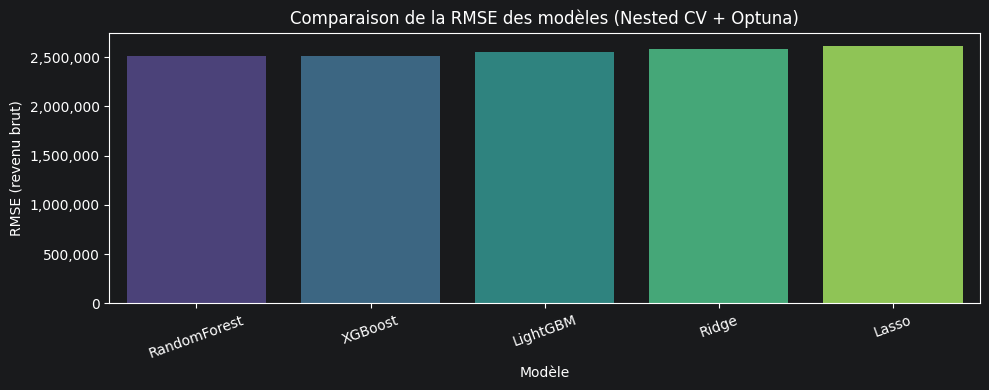

In [16]:
metrics_df = results_to_dataframe(results)

print("Synthèse des performances out-of-fold :")
display(metrics_df)

plt.figure(figsize=(10, 4))
sns.barplot(x=metrics_df.index, y=metrics_df["RMSE"], hue=metrics_df.index, palette="viridis", legend=False)
plt.title("Comparaison de la RMSE des modèles (Nested CV + Optuna)")
plt.ylabel("RMSE (revenu brut)")
plt.xlabel("Modèle")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Analyse des résultats — Comparaison OOF

#### Résultats réels

| Modèle | RMSE OOF | MAE OOF | R² OOF | Final inner RMSE |
|---|---|---|---|---|
| **RandomForest** | **2 508 157** | **1 543 509** | **+0.045** | 2 434 653 |
| XGBoost | 2 515 764 | 1 566 831 | +0.039 | 2 450 607 |
| LightGBM | 2 552 830 | 1 618 506 | +0.011 | **2 408 221** |
| Ridge | 2 586 860 | 1 652 310 | **-0.016** | 2 512 399 |
| Lasso | 2 616 175 | 1 629 403 | **-0.039** | 2 510 044 |

#### Ce que ça dit sur les données et les modèles

**1. Les arbres battent les modèles linéaires — l'hypothèse de l'EDA est confirmée.**
Ridge et Lasso ont un R² *négatif* : ils sont moins précis que de simplement prédire la moyenne des revenus pour tout le monde. Les features P n'ont pas de relation linéaire exploitable. Les arbres (RF, XGB, LGB) ont un R² positif : ils captent bien des relations non-linéaires et des interactions entre features.

**2. Les écarts entre modèles sont très faibles.**
Seulement 108 000 TRY séparent le meilleur (RF 2.508M) du moins bon parmi les arbres (LGB 2.553M), soit ~4% d'écart. Sur 137 lignes, cette différence n'est pas statistiquement significative — RandomForest est le meilleur ici, mais il pourrait être devancé sur un autre split.

**3. Le R² de 0.045 est bas — mais cohérent avec les données.**
Le meilleur modèle n'explique que **4.5% de la variance** des revenus. Ce n'est pas un échec : l'EDA a montré que les features P ont au maximum r=0.19 avec revenue. Le signal prédictif est intrinsèquement faible dans ce dataset.

**4. LightGBM sur-apprend davantage que RandomForest.**
LightGBM a le meilleur *final inner RMSE* (2 408 221) mais un *OOF RMSE* plus élevé que RF (2 553 K vs 2 508 K). C'est exactement l'optimisme de sélection : LightGBM s'adapte mieux aux 137 lignes en interne, mais généralise moins bien sur les folds de validation.

## 6. Analyse des prédictions du meilleur modèle

Meilleur modèle candidat : RandomForest
RMSE OOF : 2,508,157.68
MAE OOF : 1,543,509.57
R2 OOF : 0.0451
Hyperparamètres retenus sur toutes les données : {'add_sparse_flags': False, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'log2'}


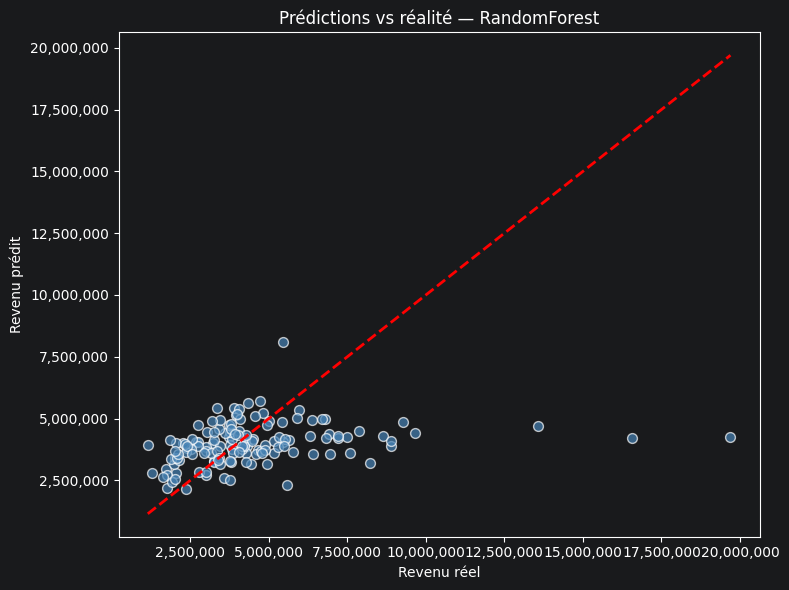

In [17]:
best_model_name = metrics_df["RMSE"].idxmin()
best_preds = results[best_model_name]["predictions"]

print(f"Meilleur modèle candidat : {best_model_name}")
print(f"RMSE OOF : {results[best_model_name]['RMSE']:,.2f}")
print(f"MAE OOF : {results[best_model_name]['MAE']:,.2f}")
print(f"R2 OOF : {results[best_model_name]['R2']:.4f}")
print(f"Hyperparamètres retenus sur toutes les données : {results[best_model_name]['final_best_params']}")

plt.figure(figsize=(8, 6))
plt.scatter(y, best_preds, alpha=0.7, color="steelblue", edgecolors="white", s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Revenu réel")
plt.ylabel("Revenu prédit")
plt.title(f"Prédictions vs réalité — {best_model_name}")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


### Observations — Analyse du meilleur modèle : RandomForest

#### Métriques finales

| Métrique | Valeur | Interprétation |
|---|---|---|
| RMSE OOF | **2 508 157 TRY** | Erreur typique ≈ 56% de la médiane des revenus (3.9M TRY) |
| MAE OOF | **1 543 509 TRY** | En moyenne, le modèle se trompe de 1.5M TRY par restaurant |
| R² OOF | **0.0451** | 4.5% de la variance expliquée — signal prédictif intrinsèquement faible |

#### Hyperparamètres retenus (entraînement final sur 137 lignes)

```
n_estimators   = 400
max_depth      = 8
min_samples_leaf = 2
max_features   = 'log2'
add_sparse_flags = False
```

`max_features='log2'` : à chaque split, le RF ne considère que log2(40) ≈ 5 features sur 40. Cette contrainte forte réduit la corrélation entre les arbres → meilleure généralisation sur un dataset aussi petit.

`add_sparse_flags=False` dans le modèle final : les 17 flags binaires des features sparses n'améliorent pas la performance. Résultat mitigé aussi en nested CV (sélectionné True dans certains folds, False dans d'autres) — le signal de ces flags est trop bruité sur 137 lignes.

#### Lecture du scatter plot "Prédictions vs Réalité"

La diagonale rouge représente la prédiction parfaite. Ce qu'on observe :

- **Outliers à fort revenu (>10M TRY)** : les restaurants d'Istanbul sont sous-estimés — le modèle les ramène vers des valeurs plus centrales (biais vers la moyenne, caractéristique des forêts aléatoires). Sur 8 outliers, aucun n'atteint probablement 10M TRY en prédiction.
- **Zone centrale 2M–5M TRY** : les prédictions sont dispersées autour de la diagonale sans biais systématique visible. C'est là que le modèle est le plus fiable.
- **Nuage peu serré** : la dispersion autour de la diagonale est large, cohérente avec un R² de 0.045. Le modèle capture une tendance, pas une relation précise.

#### Décision finale et suite du pipeline

RandomForest est retenu comme modèle de production avec les paramètres ci-dessus. Il est :
- Loggué dans MLflow comme artefact du run `NestedCV_Optuna_RandomForest`
- Reproduit par `train.py` (pipeline DVC) pour produire `models/best_model.pkl`
- Chargé par l'API FastAPI (`api/main.py`) via l'endpoint `POST /predict`